## **Question 2: Arabic Handwritten Character Search**

Ali’s younger brother is learning to write Arabic characters. One day, he wrote a character that looks like **"ب"**, and Ali wants to find **the most similar 5 images** from a dataset of handwritten Arabic characters.

📝 **Your Task:**  
Complete the missing code cells below by implementing **image search** to find the most similar 5 images to the given input character.  



# Download Data

### Query Image

In [1]:
# # Please uncomment this out when you are running this lab on google colab!
# import os

# # Set KaggleHub cache to a directory inside /content/
# os.environ["KAGGLEHUB_CACHE"] = "/content/data"

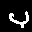

In [157]:
import kagglehub
from PIL import Image
import os

path = kagglehub.dataset_download("mohammad2012191/character")
query_image = Image.open(os.path.join(path,"char.png"))
query_image

### Arabic Characters Dataset

In [164]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("mohammad2012191/arabic-chars")

print("Path to dataset files:", dataset_path)

Path to dataset files: /kaggle/input/arabic-chars


# TASK 1: Complete the following code to build a custom dataset class for the data

In [165]:
import os
import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class ArabicHandwritingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_paths = glob.glob(os.path.join(root_dir, "*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path)
        label = int(os.path.basename(img_path).split("_")[1].split(".")[0])
        if self.transform:
            image = self.transform(image)
        return image, label

In [166]:
transform = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset = ArabicHandwritingDataset(root_dir=os.path.join(dataset_path,"chars images"), transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
print(f"Total images: {len(train_dataset)}")


query_image_transformed = transform(query_image)

Total images: 668


# TASK 2: Use EfficientNet B3 to extract features.

##### import using: 
from torchvision.models import efficientnet_b3

In [167]:
import torch
import torchvision.models as models
from torch import nn
from tqdm import tqdm

# Load pretrained efficientnet_b3 model
device = "cuda" if torch.cuda.is_available() else "cpu"
efficientnet = models.efficientnet_b3(pretrained=True)
efficientnet.eval().to(device)

# use efficientnet_b3 to extract features
def extract_features(image_tensor):
    image_tensor = image_tensor.to(device)
    with torch.no_grad():
        features = efficientnet.features(image_tensor)  # Extract features
        features = torch.flatten(features, start_dim=1)  # Flatten before passing to classifier
    return features

# Extract features for all images
all_features = []
image_tensors = []

for images, _ in tqdm(train_loader):
    image_tensors.append(images)
    features = extract_features(images)
    all_features.append(features.cpu())

# Convert to numpy
all_features = torch.cat(all_features).numpy()
image_tensors = torch.cat(image_tensors)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 42/42 [00:07<00:00,  5.73it/s]


In [168]:
query_image_feats = extract_features(query_image_transformed.unsqueeze(0))

# TASK 3: Get the indices of top 5 images using Cosine Similarity

In [169]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import torch

query_features = query_image_feats

# Compute cosine similarity
similarities = cosine_similarity(all_features, query_features.reshape(1, -1)).reshape(-1)

# Get top 5 similar images
top_indices = similarities.argsort()[-5:][::-1]  

# TASK 4: Plot the most 5 similar images

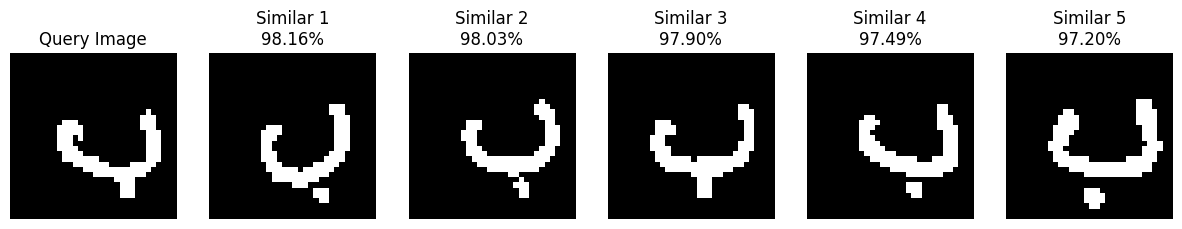

In [170]:
# Display query & retrieved images with similarity scores
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

# Query image
axes[0].imshow(query_image_transformed.permute(1, 2, 0).numpy())
axes[0].set_title("Query Image")
axes[0].axis("off")

# Retrieved similar images with similarity scores
for i, idx in enumerate(top_indices):
    image = image_tensors[idx]
    similarity_score = similarities[idx]  # Get similarity score
    axes[i + 1].imshow(image.permute(1, 2, 0).numpy())
    axes[i + 1].set_title(f"Similar {i+1}\n{100*similarity_score:.2f}%")  # Show similarity score
    axes[i + 1].axis("off")

plt.show()


# BONUS:  Get the indices of the most 5 *dissimilar* images and plot them

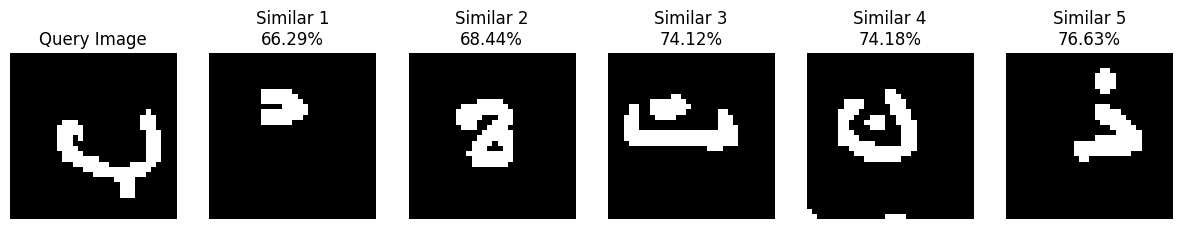

In [171]:
top_indices = similarities.argsort()[:5]  


# Display query & retrieved images with similarity scores
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

# Query image
axes[0].imshow(query_image_transformed.permute(1, 2, 0).numpy())
axes[0].set_title("Query Image")
axes[0].axis("off")

# Retrieved similar images with similarity scores
for i, idx in enumerate(top_indices):
    image = image_tensors[idx]
    similarity_score = similarities[idx]  # Get similarity score
    axes[i + 1].imshow(image.permute(1, 2, 0).numpy())
    axes[i + 1].set_title(f"Similar {i+1}\n{100*similarity_score:.2f}%")  # Show similarity score
    axes[i + 1].axis("off")

plt.show()
